In [2]:
from mdcrow import MDCrow
from langchain.callbacks import get_openai_callback
from datetime import datetime
import os 
import traceback

In [3]:
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '../'))
sys.path.append(parent_dir)
from robustness_prompts import get_prompt # noqa: E402

prompt_9_natural = get_prompt("natural", 9)

prompt_9_natural

'Simulate 1LYZ for 1ps at 300 K and for 1ps at 400K. Report the secondary structure assignments of the downloaded PDB structure and any known binding or active sites. Compute SASA and radius of gyration of the 300K simulation. Compute RMSD of both simulations.'

In [4]:
llm_model = "together/meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo"
tools = "all"

In [5]:
agent = MDCrow(
    agent_type="Structured", 
    model=llm_model, 
    top_k_tools=tools, 
    use_memory=False,
    streaming=False,
    verbose=True,
)
with get_openai_callback() as cb:
    chat_start = datetime.now()
    try:
        response = agent.run(prompt_9_natural, callbacks=[cb])
        print(response)
    except Exception as e:
        exc_type, exc_value, exc_traceback = sys.exc_info()
        print(f'{type(e).__name__}:{e}')
        print("".join(traceback.format_exception(exc_type, exc_value, exc_traceback)))
    chat_end = datetime.now()
    total_runtime = (chat_end - chat_start).total_seconds()
    print(cb)
    print(f"Total runtime: {total_runtime:.2f}s")



> Entering new AgentExecutor chain...
Thought: To solve this problem, we need to first download the PDB structure of 1LYZ, then simulate it at 300 K and 400 K for 1 ps each. We also need to compute the secondary structure assignments, SASA, radius of gyration, and RMSD of the simulations.

Action:
```
{
  "action": "PDBFileDownloader",
  "action_input": "1LYZ"
}
```
PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_180224
Thought:Thought: Now that we have the PDB file, we can simulate it at 300 K and 400 K for 1 ps each. We will use the SetUpandRunFunction tool to set up and run the simulations.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_180224",
    "forcefield_files": ["amber99sbildn.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "PME",
      "nonbondedCutoff": "1.0 * nanometers",
      "ewaldErrorTolerance": 0.0005,
      "constraints": "HBonds",
      "rigidWater": true,

<Figure size 640x480 with 0 Axes>

Could not parse LLM output: Thought: Now that we have the PDB file, we can simulate it at 300 K and 400 K for 1 ps each. We will use the SetUpandRunFunction tool to set up and run the simulations.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_215102",
    "forcefield_files": ["amber14-allatom-forcefield.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "NoCutoff",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "None",
      "rigidWater": false,
      "constraintTolerance": None,
      "solvate": false
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 100,
      "record_params": ["step", "potentialEnergy", "temperat

Could not parse LLM output: Thought: Now that we have the PDB file, we can simulate it at 300 K and 400 K for 1 ps each. We will use the SetUpandRunFunction tool to set up and run the simulations.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_215102",
    "forcefield_files": ["amber14-allatom-forcefield.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "NoCutoff",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "None",
      "rigidWater": false,
      "constraintTolerance": None,
      "solvate": false
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 100,
      "record_params": ["step", "potentialEnergy", "temperat

Could not parse LLM output: Thought: To continue the simulation, we need to run the SetUpandRunFunction tool again with the same parameters but with a different temperature (400 K). We also need to compute the secondary structure assignments of the downloaded PDB structure, SASA, radius of gyration, and RMSD of the simulations. We also need to find any known binding or active sites of the protein.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_215102",
    "forcefield_files": ["amber14-allatom-forcefield.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "NoCutoff",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "None",
      "rigidWater": false,
      "constraintTolerance": None,
      "solvate": false
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "400 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pres

...

Could not parse LLM output: Thought: Now that we have the PDB file, we can simulate it at 300 K and 400 K for 1 ps each. We will use the SetUpandRunFunction tool to set up and run the simulations.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_215140",
    "forcefield_files": ["amber14-allatom-forcefield.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "NoCutoff",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "None",
      "rigidWater": false,
      "constraintTolerance": None,
      "solvate": false
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 100,
      "record_params": ["step", "potentialEnergy", "temperat

Thought: To solve this problem, we need to first download the PDB structure of 1LYZ, then simulate it at 300 K and 400 K for 1 ps each. After that, we can compute the secondary structure assignments, SASA, radius of gyration, and RMSD of the simulations. We also need to find any known binding or active sites of the protein.

Action:
```
{
  "action": "PDBFileDownloader",
  "action_input": "1LYZ"
}
```
PDB file found with this ID: 1LYZ

Observation: Succeeded. Downloaded the PDB file:1LYZ_215203
Thought:

Could not parse LLM output: Thought: Now that we have the PDB file, we can simulate it at 300 K and 400 K for 1 ps each. We will use the SetUpandRunFunction tool to set up and run the simulations.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_215203",
    "forcefield_files": ["amber14-allatom-forcefield.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "NoCutoff",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "None",
      "rigidWater": false,
      "constraintTolerance": None,
      "solvate": false
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 100,
      "record_params": ["step", "potentialEnergy", "temperat

Could not parse LLM output: Thought: Now that we have the PDB file, we can simulate it at 300 K and 400 K for 1 ps each. We will use the SetUpandRunFunction tool to set up and run the simulations.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_215203",
    "forcefield_files": ["amber14-allatom-forcefield.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "NoCutoff",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "None",
      "rigidWater": false,
      "constraintTolerance": None,
      "solvate": false
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 100,
      "record_params": ["step", "potentialEnergy", "temperat

Could not parse LLM output: Thought: Now that we have the PDB file, we can simulate it at 300 K and 400 K for 1 ps each. We will use the SetUpandRunFunction tool to set up and run the simulations.

Action:
```
{
  "action": "SetUpandRunFunction",
  "action_input": {
    "pdb_id": "1LYZ_215203",
    "forcefield_files": ["amber14-allatom-forcefield.xml"],
    "save": true,
    "system_params": {
      "nonbondedMethod": "NoCutoff",
      "nonbondedCutoff": "1 * nanometers",
      "constraints": "None",
      "rigidWater": false,
      "constraintTolerance": None,
      "solvate": false
    },
    "integrator_params": {
      "integrator_type": "LangevinMiddle",
      "Temperature": "300 * kelvin",
      "Friction": "1.0 / picoseconds",
      "Timestep": "0.002 * picoseconds",
      "Pressure": "1.0 * bar"
    },
    "simulation_params": {
      "Ensemble": "NVT",
      "Number of Steps": 500,
      "record_interval_steps": 100,
      "record_params": ["step", "potentialEnergy", "temperat

In [6]:
registry = agent.path_registry
print(registry.list_path_names_and_descriptions().replace(",", "\n"))

Files found in registry: 1LYZ_180224: PDB file downloaded from RSCB
 PDBFile ID: 1LYZ_180224
 1LYZ_180229: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 1LYZ_180238: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 1LYZ_180247: Cleaned File:  Removed Heterogens
 and Water Removed.  Replaced Nonstandard Residues. Added Hydrogens at pH 7.0. Missing Atoms added and nonstandard residues replaced. 
 top_sim0_180249: Initial positions for simulation sim0_180249
 sim0_180249: Basic Simulation of Protein 1LYZ_180247
 rec0_180250: Simulation trajectory for protein 1LYZ_180247 and simulation sim0_180249
 rec1_180250: Simulation state log for protein 1LYZ_180247 and simulation sim0_180249
 rec2_180250: Simulation pdb frames for protein 1LYZ_180247 and simu

In [10]:
# make sure pdb was downloaded
assert os.path.exists(registry.get_mapped_path("1LYZ_180224"))

In [11]:
# make sure dssp was computed correctly
from mdcrow.tools.base_tools import ComputeDSSP

dssp = ComputeDSSP(registry)
dssp._run(traj_file= "1LYZ_180224", target_frames="first")

"{'residues in helix': 50, 'residues in strand': 14, 'residues in coil': 65, 'residues not assigned, not a protein residue': 101}"

In [9]:
# make sure the sites were found
from mdcrow.tools.base_tools import GetAllKnownSites

get_all_known_sites = GetAllKnownSites()
get_all_known_sites._run(query="1LYZ", primary_accession="")

"Active Sites: [{'start': 53, 'start_modifier': 'EXACT', 'end': 53, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}, {'start': 71, 'start_modifier': 'EXACT', 'end': 71, 'end_modifier': 'EXACT', 'description': '', 'evidences': [{'evidenceCode': 'ECO:0000255', 'source': 'PROSITE-ProRule', 'id': 'PRU00680'}]}]\nNo known binding sites.\nNo other relevant sites."

In [12]:
# make sure trajectory and topology exist
traj_path_1 = registry.get_mapped_path("rec0_180250")
top_path_1 = registry.get_mapped_path("top_sim0_180249")

assert os.path.exists(traj_path_1)
assert os.path.exists(top_path_1)

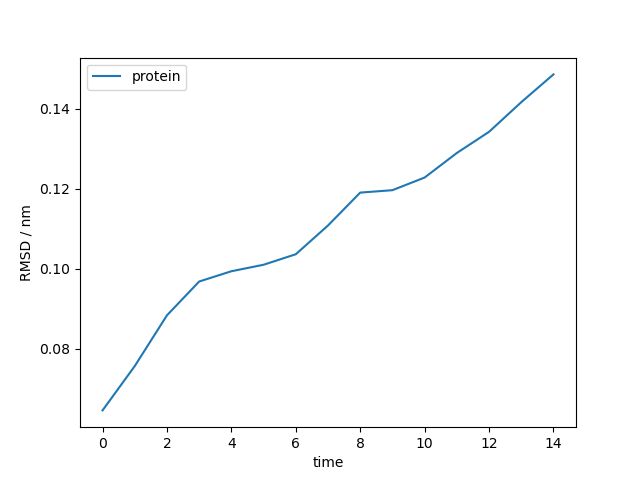

In [16]:
# make sure rmsd plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_180353'))

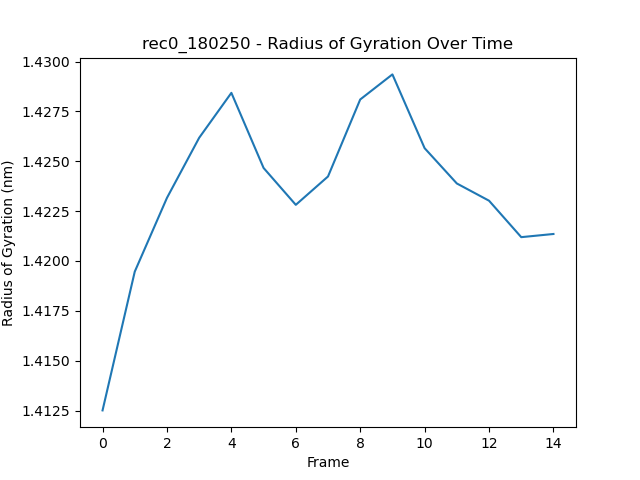

In [15]:
# make sure rgy plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_180350'))

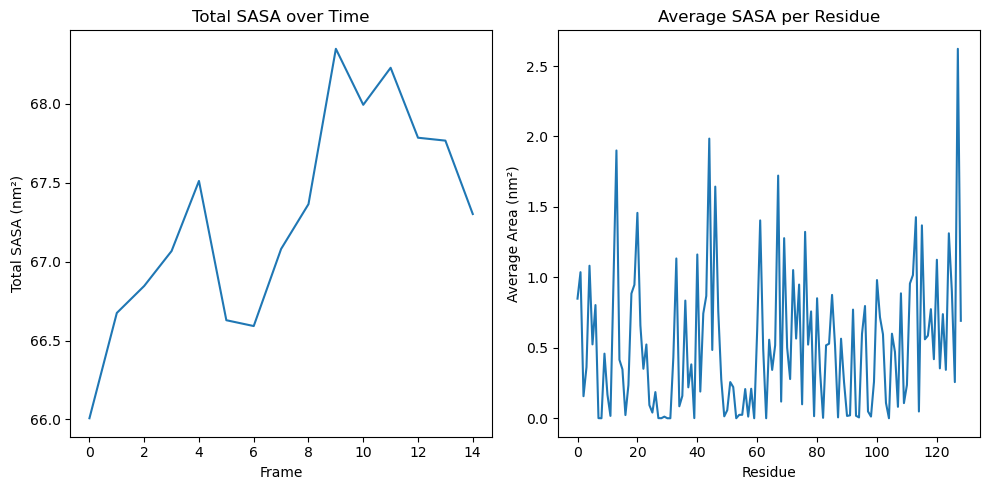

In [14]:
# make sure sasa plot was generated
from IPython.display import Image
Image(filename=registry.get_mapped_path('fig0_180347'))

In [13]:
# make sure trajectory and topology exist (sim2)
traj_path_2 = registry.get_mapped_path("rec0_180319")
top_path_2 = registry.get_mapped_path("top_sim0_180319")

assert os.path.exists(traj_path_2)
assert os.path.exists(top_path_2)

In [18]:
# # make sure rmsd plot was generated (sim2)
# from IPython.display import Image
# Image(filename=registry.get_mapped_path('fig0_xxxx'))

In [9]:
#verify the total cost
def calculate_llm_cost(input_tokens, output_tokens, model):
    if model == 'meta-llama/Meta-Llama-3.1-70B-Instruct-Turbo':
        model = "llama-v3p1-70b-instruct"
    elif model == 'meta-llama/Meta-Llama-3.1-405B-Instruct-Turbo':
        model = "llama-v3p1-405b-instruct"
    pricing_2024 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 5/1e6, "output": 15/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
        "claude-3-opus": {"input": 15/1e6, "output": 75/1e6},
        "claude-3.5-sonnet": {"input": 3/1e6, "output": 15/1e6},
    }
    pricing_2025 = {
        "gpt-4-1106-preview": {"input": 10/1e6, "output": 30/1e6},
        "gpt-3.5-turbo-0125": {"input": 0.5/1e6, "output": 1.5/1e6},
        "gpt-4-turbo-2024-04-09": {"input": 10/1e6, "output": 30/1e6},
        "gpt-4o-2024-08-06": {"input": 2.5/1e6, "output": 10/1e6},
        "llama-v3p1-70b-instruct": {"input": 0.9/1e6, "output": 0.9/1e6},
        "llama-v3p1-405b-instruct": {"input": 3/1e6, "output": 3/1e6},
    }
    
    prices = pricing_2025[model]
    cost = (input_tokens * prices["input"]) + (output_tokens * prices["output"])
    return round(cost, 6)

llm_cost = calculate_llm_cost(cb.prompt_tokens, cb.completion_tokens, agent.llm.model_name)
print('Input tokens:',cb.prompt_tokens)
print('Output tokens:',cb.completion_tokens)
print('LLM costs: $',llm_cost)

Input tokens: 150656
Output tokens: 2836
LLM costs: $ 0.138143
